Permuted element: O, [ 6 26 27 31 32 38 39], permutation: [39 26 38  6 27 31 32]
Permuted element: N, [ 7 12 18 24], permutation: [12 24  7 18]
Permuted element: C, [ 0  1  2  3  4  5  8  9 10 11 13 14 15 16 17 19 20 21 22 23 25 28 29 30
 33 34 35 36 37 40], permutation: [19 23  1 40 15  9 35 14  8 20 29 11 37 22 34 36  2  3  0 28 16 21 17 30
  5 10 25  4 33 13]
Final permutation: [19 23  1 40 15  9 39 12 35 14  8 20 24 29 11 37 22 34  7 36  2  3  0 28
 18 16 26 38 21 17 30  6 27  5 10 25  4 33 31 32 13]




/tmp/ipykernel_219299/1741741129.py:91: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(R1), cmap='viridis')


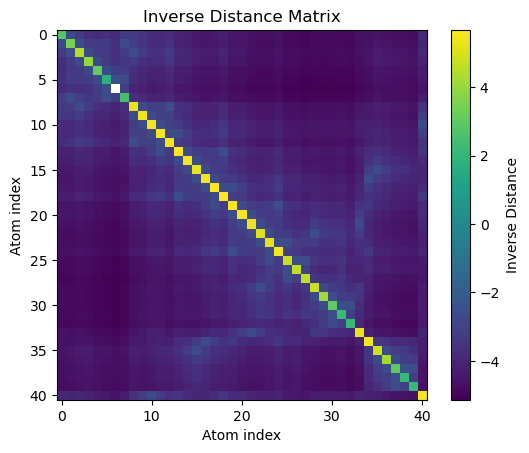

/tmp/ipykernel_219299/1741741129.py:98: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(R2), cmap='viridis')


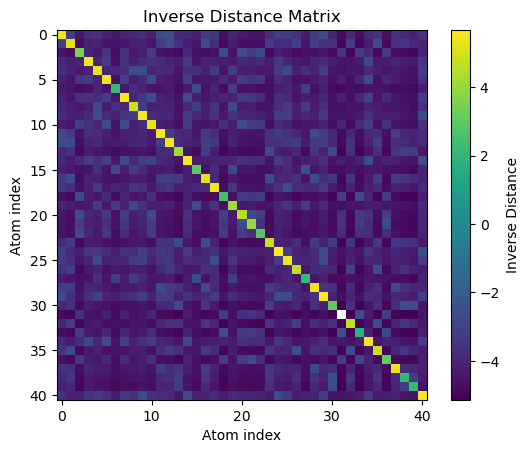

/tmp/ipykernel_219299/1741741129.py:109: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(R2), cmap='viridis')


0 0.0 839.1870387081083
0.0


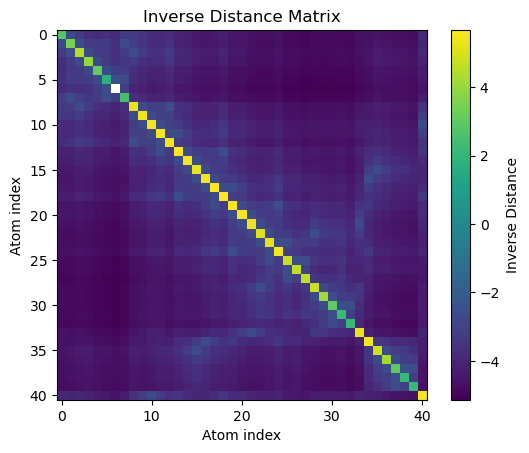

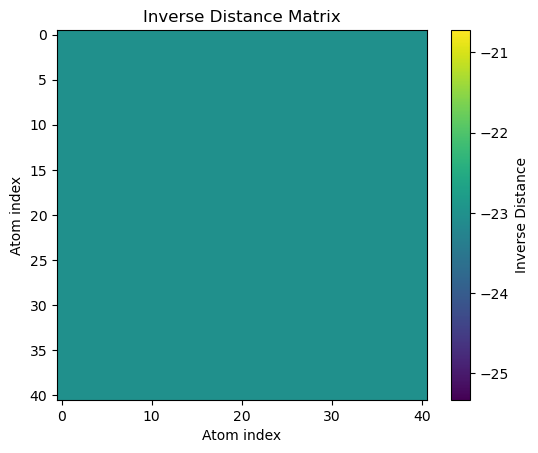

In [41]:
import random

import matplotlib.pyplot as plt
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem

from rapiat import geometry


def chemical_properties(mol):
    props = []
    a = np.random.random(100)
    for atom in mol.GetAtoms():
        x = (
            a[0] * atom.GetDegree()
            + a[1] * atom.GetTotalNumHs()
            + a[2] * atom.GetIsAromatic() * 2
            + a[3] * atom.GetHybridization().real
            + a[4] * atom.GetFormalCharge()
            + a[5] * atom.GetMass()
        )
        props.append(float(x))
    return props


def message_passing(props, mol):
    # Graph convolution: mean aggregation of neighbors
    new_props = []
    for atom in mol.GetAtoms():
        idx = atom.GetIdx()
        neighbor_idxs = [n.GetIdx() for n in atom.GetNeighbors()]
        # Include self if desired (optional)
        values = [props[idx]] + [props[n_idx] for n_idx in neighbor_idxs]
        new_props.append(sum(values) / len(values))  # Mean aggregation
    return new_props


def feature_matrix(mol, topology_weight=1.0, geometry_weight=1.0, hydrogens=False, depth=10):
    if not hydrogens:
        mol = Chem.RemoveHs(mol)  # remove hydrogens for distance calculations

    X = geometry.get_conformer_positions(mol)
    R = geometry.inverse_distance_matrix(X)

    props = chemical_properties(mol)
    for i in range(depth):
        props = message_passing(props, mol)
        props = np.array(props)
        props -= np.mean(props)
        props /= np.std(props)
    props -= np.min(props)

    R[:, :, :] *= geometry_weight  # weight geometry part
    # set diagonal to properties0
    for i, atom in enumerate(mol.GetAtoms()):
        # print(f"Atom {i}: {atom.GetSymbol()}, Property: {props[i]}")
        R[:, i, i] = topology_weight * props[i]  # weight topology part
    return R, mol


def random_permutation(R, mol, seed=42):
    atomic_symbols = np.array([atom.GetSymbol() for atom in mol.GetAtoms()])
    elements = list(set(atomic_symbols))

    if seed >= 0:
        random.seed(seed)
    Pref = np.arange(len(atomic_symbols))
    for element in elements:
        atom_ids = np.where(atomic_symbols == element)[0]
        # if element == 'C':
        # continue
        P = atom_ids.copy()
        random.shuffle(P)
        print(f"Permuted element: {element}, {atom_ids}, permutation: {P}")
        Pref[atom_ids] = P
    print(f"Final permutation: {Pref}\n\n")
    R2 = R[Pref][:, Pref]
    return R2, Pref


biliverdin = (
    "CC1=C(CCC(=O)N1)C2=CC(=C(N2)C3=CC(=C(C(=N3)C4=CC(=C(C(=N4)C(=O)O)CCC(=O)O)C)C)CCC(=O)O)C"
)
mol = Chem.AddHs(Chem.MolFromSmiles(biliverdin))
AllChem.EmbedMultipleConfs(mol, numConfs=1)

R1, mol = feature_matrix(mol, topology_weight=100.0, geometry_weight=0.1, hydrogens=False, depth=6)

# Create a random permutation of the inverse distance matrix
R1 = R1[0].copy()
R2 = R1.copy()
R2, P = random_permutation(R2, mol, seed=-1)

plt.imshow(np.log(R1), cmap="viridis")
plt.colorbar(label="Inverse Distance")
plt.title("Inverse Distance Matrix")
plt.xlabel("Atom index")
plt.ylabel("Atom index")
plt.show()

plt.imshow(np.log(R2), cmap="viridis")
plt.colorbar(label="Inverse Distance")
plt.title("Inverse Distance Matrix")
plt.xlabel("Atom index")
plt.ylabel("Atom index")
plt.show()

R2, P_best = geometry.sample_align_permutations(R1, R2, mol, 20, rng=np.random.default_rng())
# R2, P = geometry.permute_R(R1, R2, mol)

print(np.linalg.norm(R1 - R2))
plt.imshow(np.log(R2), cmap="viridis")
plt.colorbar(label="Inverse Distance")
plt.title("Inverse Distance Matrix")
plt.xlabel("Atom index")
plt.ylabel("Atom index")
plt.show()

plt.imshow(np.log(np.abs(R2 - R1) + 1e-10), cmap="viridis")
plt.colorbar(label="Inverse Distance")
plt.title("Inverse Distance Matrix")
plt.xlabel("Atom index")
plt.ylabel("Atom index")
plt.show()